### **1. Import Library**

In [1]:
# koneksi ke database gold layer
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# kalau belum terinstal, jalankan dulu di terminal (bukan di notebook):
# pip install xgboost lightgbm
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sqlalchemy import text
from datetime import datetime, timezone
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# ambil connection string dari .env, jangan pernah hardcode credential di kode
load_dotenv()
db_url = os.getenv("GOLD_DATABASE_URL")

engine = create_engine(db_url)

print("Library Sukses di Import")

Library Sukses di Import


### **2. Ambil Query Pergerakan Stock**

In [2]:
# query data pergerakan stok, sudah termasuk kolom ID untuk kebutuhan nanti
query = """
SELECT 
    f.obat_id,
    o.nama_generik,
    o.obat_kode,
    o.kategori,
    f.gudang_id,
    g.nama AS nama_gudang,
    f.tanggal_id,
    d.tanggal,
    d.hari,
    d.is_weekend,
    f.batch_id,
    f.tanggal_kadaluwarsa,
    f.jumlah_masuk,
    f.jumlah_keluar
FROM gold.fact_stock_movement f
JOIN gold.dim_obat o ON f.obat_id = o.obat_id
JOIN gold.dim_gudang g ON f.gudang_id = g.gudang_id
JOIN gold.dim_waktu d ON f.tanggal_id = d.tanggal_id
ORDER BY d.tanggal
"""

df = pd.read_sql(query, engine)

### **3. Cek Validasi Data**

In [3]:
# cek dasar, wajib dilakukan sebelum analisis apapun
print("Jumlah baris dan kolom:", df.shape)
df.info()

print("\nRentang tanggal:", df["tanggal"].min(), "sampai", df["tanggal"].max())
print("Jumlah obat unik:", df["obat_id"].nunique())
print("Jumlah gudang unik:", df["gudang_id"].nunique())
print("Jumlah baris duplikat:", df.duplicated().sum())
print("Jumlah baris Missing Value:", df.isnull().sum())

Jumlah baris dan kolom: (60377, 14)
<class 'pandas.DataFrame'>
RangeIndex: 60377 entries, 0 to 60376
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   obat_id              60377 non-null  str   
 1   nama_generik         60377 non-null  str   
 2   obat_kode            60377 non-null  str   
 3   kategori             60377 non-null  str   
 4   gudang_id            60377 non-null  str   
 5   nama_gudang          60377 non-null  str   
 6   tanggal_id           60377 non-null  int64 
 7   tanggal              60377 non-null  object
 8   hari                 60377 non-null  str   
 9   is_weekend           60377 non-null  bool  
 10  batch_id             60377 non-null  str   
 11  tanggal_kadaluwarsa  60377 non-null  object
 12  jumlah_masuk         60377 non-null  int64 
 13  jumlah_keluar        60377 non-null  int64 
dtypes: bool(1), int64(3), object(2), str(8)
memory usage: 6.0+ MB

Rentang tangga

In [4]:
# Intip isi baris duplikat sebelum diputuskan untuk Drop
baris_duplikat = df[df.duplicated(keep=False)].sort_values(by=["batch_id", "tanggal"])
print(baris_duplikat[["obat_id", "gudang_id", "batch_id", "tanggal", "jumlah_masuk", "jumlah_keluar"]])

       obat_id gudang_id         batch_id     tanggal  jumlah_masuk  \
53289  OBT0221      GD02  FUR-20251123-17  2026-05-03             0   
53318  OBT0221      GD02  FUR-20251123-17  2026-05-03             0   
46965  OBT0415      GD04  MET-20250828-15  2026-02-15             0   
46974  OBT0415      GD04  MET-20250828-15  2026-02-15             0   
1048   OBT0480      GD02  PCT-20240727-01  2024-08-08             0   
1092   OBT0480      GD02  PCT-20240727-01  2024-08-08             0   
17129  OBT0541      GD02  SAL-20250219-08  2025-02-19           283   
17172  OBT0541      GD02  SAL-20250219-08  2025-02-19           283   
23722  OBT0541      GD02  SAL-20250219-08  2025-05-10             0   
23766  OBT0541      GD02  SAL-20250219-08  2025-05-10             0   
4763   OBT0572      GD03  SIM-20240831-02  2024-09-22             0   
4787   OBT0572      GD03  SIM-20240831-02  2024-09-22             0   

       jumlah_keluar  
53289              6  
53318              6  
46965  

In [5]:
# Hapus duplikat yang sudah tervalidasi memang nilainya sama, catat jumlahnya untuk dokumentasi EDA
jumlah_sebelum = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
jumlah_sesudah = df.shape[0]

print(f"Baris sebelum dedup: {jumlah_sebelum}")
print(f"Baris sesudah dedup: {jumlah_sesudah}")
print(f"Baris yang dibuang karena duplikat: {jumlah_sebelum - jumlah_sesudah}")

Baris sebelum dedup: 60377
Baris sesudah dedup: 60371
Baris yang dibuang karena duplikat: 6


Ditemukan data duplikat 6 baris di gold layer yang seharusnya sudah dedup di sisi DE, kemungkinan celah kecil di proses transform, dampak diabaikan karena sangat kecil hanya 0.01%

### **4. Konversi Tanggal & Tanggal Kadaluwarsa ke DateTime**

In [6]:
# konversi kolom tanggal ke tipe datetime yang benar
df["tanggal"] = pd.to_datetime(df["tanggal"])
df["tanggal_kadaluwarsa"] = pd.to_datetime(df["tanggal_kadaluwarsa"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60371 entries, 0 to 60370
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   obat_id              60371 non-null  str          
 1   nama_generik         60371 non-null  str          
 2   obat_kode            60371 non-null  str          
 3   kategori             60371 non-null  str          
 4   gudang_id            60371 non-null  str          
 5   nama_gudang          60371 non-null  str          
 6   tanggal_id           60371 non-null  int64        
 7   tanggal              60371 non-null  datetime64[s]
 8   hari                 60371 non-null  str          
 9   is_weekend           60371 non-null  bool         
 10  batch_id             60371 non-null  str          
 11  tanggal_kadaluwarsa  60371 non-null  datetime64[s]
 12  jumlah_masuk         60371 non-null  int64        
 13  jumlah_keluar        60371 non-null  int64        
dtypes

### **5. Validasi Angka Jumlah Masuk dan Jumlah Keluar**

In [7]:
# cell 7: cek statistik dasar dan cari nilai yang janggal
print(df[["jumlah_masuk", "jumlah_keluar"]].describe())

print("\nJumlah baris dengan jumlah_masuk negatif:", (df["jumlah_masuk"] < 0).sum())
print("Jumlah baris dengan jumlah_keluar negatif:", (df["jumlah_keluar"] < 0).sum())

       jumlah_masuk  jumlah_keluar
count  60371.000000   60371.000000
mean      23.686389      17.681552
std      149.478328      13.396657
min        0.000000       0.000000
25%        0.000000       9.000000
50%        0.000000      14.000000
75%        0.000000      24.000000
max     2542.000000     172.000000

Jumlah baris dengan jumlah_masuk negatif: 0
Jumlah baris dengan jumlah_keluar negatif: 0


In [8]:
# konfirmasi asumsi: satu baris cuma mewakili satu jenis kejadian
# (masuk ATAU keluar, tidak pernah dua-duanya sekaligus di baris yang sama)
baris_campur = df[(df["jumlah_masuk"] > 0) & (df["jumlah_keluar"] > 0)]
print(f"Jumlah baris dengan masuk dan keluar sama-sama > 0: {len(baris_campur)}")
if len(baris_campur) <= 0:
  print("\nAsumsi benar dimana merupakan kejadian konsumsi bukan kejadian penerimaan barang")
else:
  print("\nAsumsi salah dimana merupakan kejadian penerimaan barang bukan kejadian konsumsi")

Jumlah baris dengan masuk dan keluar sama-sama > 0: 0

Asumsi benar dimana merupakan kejadian konsumsi bukan kejadian penerimaan barang


### **6. Agresi Level Harian Sebelum Forecasting**

In [9]:
# agregasi ke level harian per kombinasi obat-gudang
# perlu di-groupby dulu karena dalam satu hari bisa ada lebih dari satu baris
# untuk kombinasi obat-gudang yang sama (beberapa batch bergerak di hari sama)
demand_harian = (
    df.groupby(["obat_id", "nama_generik", "gudang_id", "nama_gudang", "tanggal"])
    .agg(jumlah_keluar=("jumlah_keluar", "sum"), jumlah_masuk=("jumlah_masuk", "sum"))
    .reset_index()
)

print(f"Jumlah baris setelah agregasi harian: {len(demand_harian)}")

Jumlah baris setelah agregasi harian: 57147


### **7. Melengkapi Isi Nol untuk hari yang tidak punya baris sama sekali**

In [10]:
# lengkapi kalender penuh per kombinasi obat-gudang, isi nol untuk hari
# yang tidak punya baris sama sekali (bukan data hilang, tapi memang nol)
tanggal_lengkap = pd.date_range(df["tanggal"].min(), df["tanggal"].max(), freq="D")

daftar_lengkap = []
for (obat_id, nama_generik, gudang_id, nama_gudang), grup in demand_harian.groupby(
    ["obat_id", "nama_generik", "gudang_id", "nama_gudang"]
):
    grup_lengkap = (
        grup.set_index("tanggal")
        .reindex(tanggal_lengkap)
        .rename_axis("tanggal")
        .reset_index()
    )
    grup_lengkap["obat_id"] = obat_id
    grup_lengkap["nama_generik"] = nama_generik
    grup_lengkap["gudang_id"] = gudang_id
    grup_lengkap["nama_gudang"] = nama_gudang
    grup_lengkap["jumlah_keluar"] = grup_lengkap["jumlah_keluar"].fillna(0)
    grup_lengkap["jumlah_masuk"] = grup_lengkap["jumlah_masuk"].fillna(0)
    daftar_lengkap.append(grup_lengkap)

demand_harian_lengkap = pd.concat(daftar_lengkap, ignore_index=True)

jumlah_hari = len(tanggal_lengkap)
print(f"Jumlah baris sebelum dilengkapi : {len(demand_harian)}")
print(f"Jumlah baris sesudah dilengkapi : {len(demand_harian_lengkap)}")
print(f"Ekspektasi (20 obat x 4 gudang x {jumlah_hari} hari): {20 * 4 * jumlah_hari}")

Jumlah baris sebelum dilengkapi : 57147
Jumlah baris sesudah dilengkapi : 58480
Ekspektasi (20 obat x 4 gudang x 731 hari): 58480


### **8. Pengechcekan Presentasi Hari dengan Demand Nol**

Persentase hari dengan demand nol per obat:
nama_generik
Human Insulin Prandial: insulin regular                              3.625171
glibenklamid                                                         2.975376
salbutamol                                                           2.872777
seftriakson                                                          2.701778
parasetamol                                                          2.633379
kaptopril                                                            2.530780
ranitidin                                                            2.496580
furosemid                                                            2.393981
deksametason                                                         2.291382
simvastatin                                                          2.257182
loratadin                                                            2.222982
sefiksim                                                             2.222982
metroni

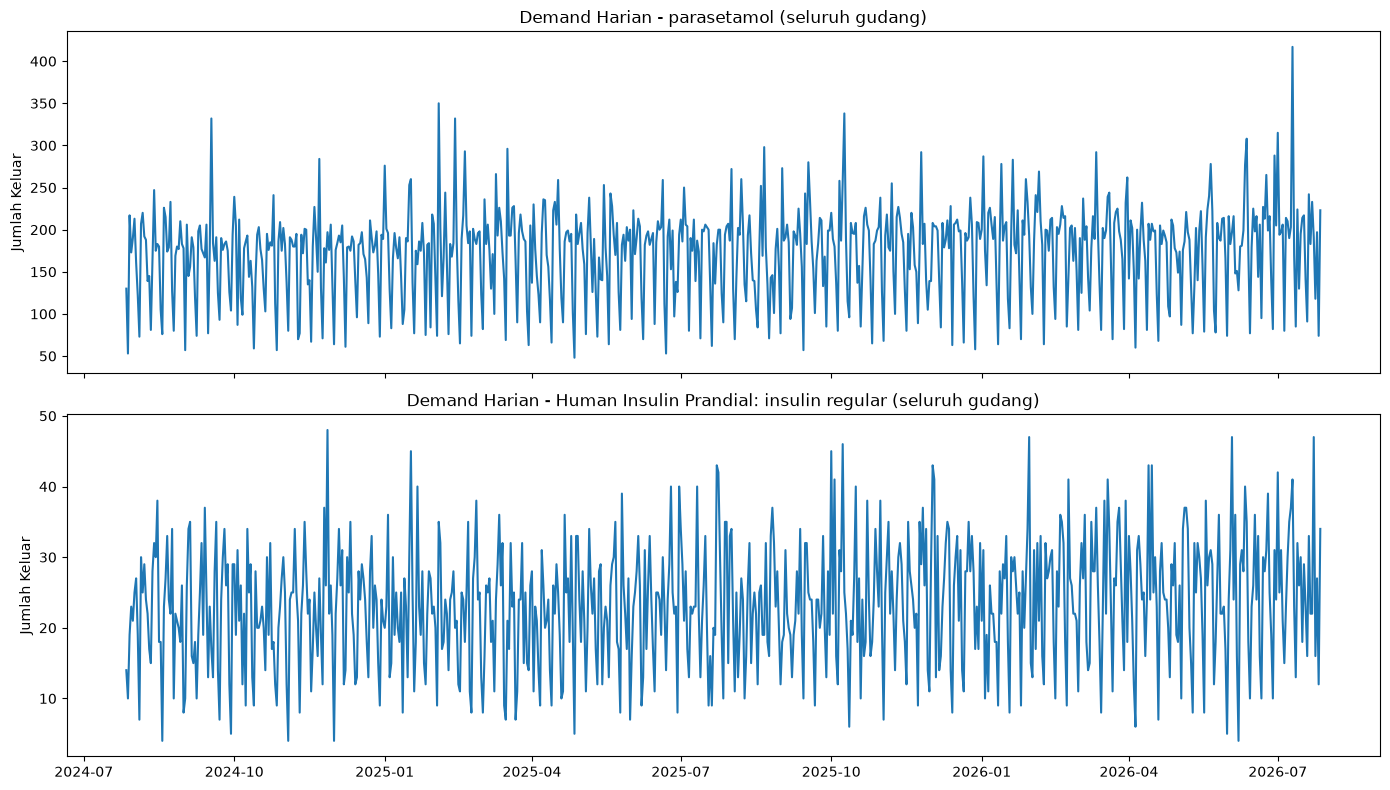

In [11]:
# cek persentase hari dengan demand nol per obat
# obat dengan demand rendah biasanya lebih intermiten (banyak hari nol),
# ini penting diketahui sebelum pilih model forecasting nanti
persentase_hari_nol = (
    demand_harian_lengkap.groupby("nama_generik")
    .apply(lambda g: (g["jumlah_keluar"] == 0).mean() * 100)
    .sort_values(ascending=False)
)

print("Persentase hari dengan demand nol per obat:")
print(persentase_hari_nol)

# visualisasi perbandingan, satu obat volume tinggi vs satu obat volume rendah
# untuk lihat langsung bedanya secara visual
contoh_obat = ["parasetamol", "Human Insulin Prandial: insulin regular"]

fig, axes = plt.subplots(len(contoh_obat), 1, figsize=(14, 8), sharex=True)

for ax, nama_obat in zip(axes, contoh_obat):
    subset = (
        demand_harian_lengkap[demand_harian_lengkap["nama_generik"] == nama_obat]
        .groupby("tanggal")["jumlah_keluar"]
        .sum()
    )
    ax.plot(subset.index, subset.values)
    ax.set_title(f"Demand Harian - {nama_obat} (seluruh gudang)")
    ax.set_ylabel("Jumlah Keluar")

plt.tight_layout()
plt.show()

### **9. Validasi Konsumsi Berdasarkan Tanggal Kadaluwarsa**

In [12]:
# validasi: apakah ada konsumsi yang tercatat Setelah tanggal kadaluwarsa
# kalau ada, berarti perhitungan sisa_stok berbasis total keseluruhan histori
# bisa salah, karena seharusnya kita hitung sisa PADA SAAT kadaluwarsa,
# bukan sisa di akhir data
konsumsi_setelah_kadaluwarsa = df[
    (df["tanggal"] > df["tanggal_kadaluwarsa"]) & (df["jumlah_keluar"] > 0)
]
print(
    f"Jumlah baris konsumsi setelah tanggal kadaluwarsa: "
    f"{len(konsumsi_setelah_kadaluwarsa)}"
)

Jumlah baris konsumsi setelah tanggal kadaluwarsa: 0


### **10. Menentukan Batas Waktu Berdasarkan Tanggal Terakhir**

In [13]:
# agregasi di level batch, pakai df yang sudah didedup dan sudah datetime
# ini fondasi untuk menurunkan label risiko kadaluwarsa
ringkasan_batch = df.groupby(
    ["batch_id", "obat_id", "nama_generik", "gudang_id", "tanggal_kadaluwarsa"]
).agg(
    total_masuk=("jumlah_masuk", "sum"),
    total_keluar=("jumlah_keluar", "sum"),
    tanggal_kejadian_pertama=("tanggal", "min"),
    tanggal_kejadian_terakhir=("tanggal", "max"),
).reset_index()

# sisa stok yang belum terpakai per batch
ringkasan_batch["sisa_stok"] = (
    ringkasan_batch["total_masuk"] - ringkasan_batch["total_keluar"]
)

print(f"Jumlah batch unik: {len(ringkasan_batch)}")
print(f"Tipe data tanggal_kadaluwarsa: {ringkasan_batch['tanggal_kadaluwarsa'].dtype}")
display(ringkasan_batch.head(10))
print("-" * 70)

# tentukan batas waktu "sekarang" berdasarkan tanggal terakhir yang ada di data
tanggal_data_terakhir = df["tanggal"].max()
print(f"Tanggal data terakhir (dianggap 'hari ini'): {tanggal_data_terakhir}")

# tandai batch mana yang tanggal kadaluwarsanya sudah lewat vs belum
# hanya batch yang sudah lewat yang bisa dipakai untuk training,
# karena cuma itu yang hasil akhirnya sudah pasti diketahui
ringkasan_batch["sudah_kadaluwarsa"] = (
    ringkasan_batch["tanggal_kadaluwarsa"] <= tanggal_data_terakhir
)

print(ringkasan_batch["sudah_kadaluwarsa"].value_counts())

# pisahkan dua kelompok
batch_untuk_training = ringkasan_batch[
    ringkasan_batch["sudah_kadaluwarsa"]
].copy()
batch_masih_berjalan = ringkasan_batch[
    ~ringkasan_batch["sudah_kadaluwarsa"]
].copy()

print(f"Batch sudah kadaluwarsa (bisa dilabeli)  : {len(batch_untuk_training)}")
print(f"Batch masih berjalan (belum bisa dilabeli): {len(batch_masih_berjalan)}")

# cek anomali dulu, sisa_stok seharusnya tidak pernah negatif
# (tidak mungkin keluar lebih banyak dari yang masuk)
anomali_sisa_negatif = batch_untuk_training[batch_untuk_training["sisa_stok"] < 0]
print(f"Jumlah batch dengan sisa_stok negatif: {len(anomali_sisa_negatif)}")

# turunkan label, sisa_stok > 0 pada saat kadaluwarsa berarti ada barang
# yang tidak terpakai, jadi otomatis jadi waste begitu lewat tanggal
# kadaluwarsa (tidak perlu ambang batas minimal, karena obat kadaluwarsa
# sisa berapapun tetap tidak bisa dipakai)
batch_untuk_training["label_risiko"] = (
    batch_untuk_training["sisa_stok"] > 0
).astype(int)

print("Distribusi label risiko (0 = habis terpakai, 1 = ada sisa/waste):")
print(batch_untuk_training["label_risiko"].value_counts())
print()
print("Proporsi:")
print(batch_untuk_training["label_risiko"].value_counts(normalize=True))

Jumlah batch unik: 2003
Tipe data tanggal_kadaluwarsa: datetime64[s]


,batch_id,obat_id,nama_generik,gudang_id,tanggal_kadaluwarsa,total_masuk,total_keluar,tanggal_kejadian_pertama,tanggal_kejadian_terakhir,sisa_stok
0,AML-20240727-01,OBT0063,amlodipin,GD01,2027-08-04,1083,1041,2024-07-27,2024-09-14,42
1,AML-20240727-01,OBT0063,amlodipin,GD02,2027-07-22,1290,1230,2024-07-27,2024-09-17,60
2,AML-20240727-01,OBT0063,amlodipin,GD03,2027-07-25,812,812,2024-07-27,2024-09-02,0
3,AML-20240727-01,OBT0063,amlodipin,GD04,2027-07-31,1183,1183,2024-07-27,2024-09-14,0
4,AML-20240823-02,OBT0063,amlodipin,GD03,2027-08-17,620,620,2024-08-23,2024-09-27,0
5,AML-20240829-02,OBT0063,amlodipin,GD04,2027-08-16,671,658,2024-08-29,2024-10-14,13
6,AML-20240904-02,OBT0063,amlodipin,GD01,2027-09-08,645,623,2024-09-04,2024-10-11,22
7,AML-20240904-02,OBT0063,amlodipin,GD02,2027-08-20,0,569,2024-09-17,2024-10-14,-569
8,AML-20240913-03,OBT0063,amlodipin,GD03,2027-09-14,1032,1011,2024-09-13,2024-11-10,21
9,AML-20240918-03,OBT0063,amlodipin,GD04,2027-09-21,839,782,2024-09-18,2024-11-11,57


----------------------------------------------------------------------
Tanggal data terakhir (dianggap 'hari ini'): 2026-07-27 00:00:00
sudah_kadaluwarsa
False    1825
True      178
Name: count, dtype: int64
Batch sudah kadaluwarsa (bisa dilabeli)  : 178
Batch masih berjalan (belum bisa dilabeli): 1825
Jumlah batch dengan sisa_stok negatif: 10
Distribusi label risiko (0 = habis terpakai, 1 = ada sisa/waste):
label_risiko
1    107
0     71
Name: count, dtype: int64

Proporsi:
label_risiko
1    0.601124
0    0.398876
Name: proportion, dtype: float64


### **11. Pengecheckan Luas Sebaran sisa_stock negatif di Training & Keluarkan Batch dengan sisa_stock negatif dari data training**

In [14]:
# cek dulu seberapa luas sebaran sisa_stok negatif, di training maupun yang masih berjalan
print("Batch sudah kadaluwarsa dengan sisa_stok negatif:")
print((batch_untuk_training["sisa_stok"] < 0).sum(), "dari", len(batch_untuk_training))

print()
print("Batch masih berjalan dengan sisa_stok negatif (sejauh ini):")
print((batch_masih_berjalan["sisa_stok"] < 0).sum(), "dari", len(batch_masih_berjalan))

# keluarkan batch dengan sisa_stok negatif dari data training
# batch ini kemungkinan besar punya baris "masuk" yang hilang di data,
# jadi total_keluar-nya tidak bisa dipercaya untuk menyimpulkan label,
# bukan soal batch ini "habis terpakai", tapi datanya memang tidak lengkap
batch_untuk_training_bersih = batch_untuk_training[
    batch_untuk_training["sisa_stok"] >= 0
].copy()

print(f"Batch sebelum dibersihkan: {len(batch_untuk_training)}")
print(f"Batch sesudah dibersihkan : {len(batch_untuk_training_bersih)}")
print()
print("Distribusi label risiko setelah pembersihan:")
print(batch_untuk_training_bersih["label_risiko"].value_counts())
print(batch_untuk_training_bersih["label_risiko"].value_counts(normalize=True))

Batch sudah kadaluwarsa dengan sisa_stok negatif:
10 dari 178

Batch masih berjalan dengan sisa_stok negatif (sejauh ini):
24 dari 1825
Batch sebelum dibersihkan: 178
Batch sesudah dibersihkan : 168

Distribusi label risiko setelah pembersihan:
label_risiko
1    107
0     61
Name: count, dtype: int64
label_risiko
1    0.636905
0    0.363095
Name: proportion, dtype: float64


### **12. Rata-rata Pendekatan Demand Gudang**

In [15]:
# hitung rata-rata demand harian per kombinasi obat-gudang dari seluruh histori
# ini dipakai sebagai proxy kecepatan konsumsi normal, bukan demand batch itu sendiri
# catatan keterbatasan: dihitung dari full histori (bukan cuma sebelum batch diterima),
# kompromi yang diambil sadar untuk skala waktu bootcamp, bukan kesalahan
rata_rata_demand = (
    demand_harian_lengkap.groupby(["obat_id", "gudang_id"])["jumlah_keluar"]
    .mean()
    .reset_index()
    .rename(columns={"jumlah_keluar": "rata_rata_demand_obat_gudang"})
)

rata_rata_demand.head()

# gabungkan kembali batch training dan batch yang masih berjalan
# supaya proses feature engineering konsisten untuk keduanya sekaligus
# (nanti yang training dipakai untuk fit model, yang masih berjalan untuk scoring)
batch_masih_berjalan_bersih = batch_masih_berjalan[
    batch_masih_berjalan["sisa_stok"] >= 0
].copy()

batch_untuk_training_bersih["kelompok"] = "training"
batch_masih_berjalan_bersih["kelompok"] = "scoring"

seluruh_batch = pd.concat(
    [batch_untuk_training_bersih, batch_masih_berjalan_bersih],
    ignore_index=True,
)

print(f"Total batch gabungan (training + scoring): {len(seluruh_batch)}")
print(seluruh_batch["kelompok"].value_counts())

# ambil tanggal_terima dari tanggal_kejadian_pertama
# (baris pertama tiap batch seharusnya adalah kejadian batch datang)
seluruh_batch["tanggal_terima"] = seluruh_batch["tanggal_kejadian_pertama"]

# hitung shelf_life dalam satuan hari, ini properti fisik batch yang sudah
# diketahui sejak batch diterima, aman dipakai sebagai fitur
seluruh_batch["shelf_life_hari"] = (
    seluruh_batch["tanggal_kadaluwarsa"] - seluruh_batch["tanggal_terima"]
).dt.days

seluruh_batch["bulan_terima"] = seluruh_batch["tanggal_terima"].dt.month

# gabungkan dengan rata-rata demand per obat-gudang
seluruh_batch = seluruh_batch.merge(
    rata_rata_demand, on=["obat_id", "gudang_id"], how="left"
)

# gabungkan dengan kategori obat dari dim_obat (ambil dari df yang sudah ada)
kategori_obat = df[["obat_id", "kategori"]].drop_duplicates()
seluruh_batch = seluruh_batch.merge(kategori_obat, on="obat_id", how="left")

# hitung fitur inti, perkiraan berapa hari dibutuhkan menghabiskan stok awal
# kalau konsumsi berjalan normal sesuai rata-rata historis
# tambahkan penjagaan pembagian nol untuk obat yang kebetulan rata-rata demand-nya nol
seluruh_batch["rasio_stok_terhadap_demand"] = np.where(
    seluruh_batch["rata_rata_demand_obat_gudang"] > 0,
    seluruh_batch["total_masuk"] / seluruh_batch["rata_rata_demand_obat_gudang"],
    np.nan,
)

# cek hasil akhir, pastikan tidak ada nilai kosong tidak terduga di fitur utama
kolom_fitur = [
    "batch_id", "obat_id", "gudang_id", "kelompok",
    "kategori", "bulan_terima",
    "total_masuk", "shelf_life_hari",
    "rata_rata_demand_obat_gudang", "rasio_stok_terhadap_demand",
    "label_risiko",
]

print("Cek missing value di kolom fitur:")
print(seluruh_batch[kolom_fitur].isnull().sum())
print()
seluruh_batch[kolom_fitur].head(10)

Total batch gabungan (training + scoring): 1969
kelompok
scoring     1801
training     168
Name: count, dtype: int64
Cek missing value di kolom fitur:
batch_id                           0
obat_id                            0
gudang_id                          0
kelompok                           0
kategori                           0
bulan_terima                       0
total_masuk                        0
shelf_life_hari                    0
rata_rata_demand_obat_gudang       0
rasio_stok_terhadap_demand         0
label_risiko                    1801
dtype: int64



,batch_id,obat_id,gudang_id,kelompok,kategori,bulan_terima,total_masuk,shelf_life_hari,rata_rata_demand_obat_gudang,rasio_stok_terhadap_demand,label_risiko
0,CAP-20240727-01,OBT0295,GD01,training,Antihipertensi,7,1152,725,21.488372,53.610390,0.0
1,CAP-20240727-01,OBT0295,GD02,training,Antihipertensi,7,983,720,21.763338,45.167704,1.0
2,CFT-20240727-01,OBT0554,GD01,training,Antibiotik,7,328,350,9.731874,33.703683,0.0
3,CFT-20240727-01,OBT0554,GD02,training,Antibiotik,7,482,373,9.852257,48.922799,1.0
4,CFT-20240727-01,OBT0554,GD03,training,Antibiotik,7,466,378,9.477428,49.169457,1.0
5,CFT-20240727-01,OBT0554,GD04,training,Antibiotik,7,300,368,9.644323,31.106383,1.0
6,CFT-20240819-02,OBT0554,GD01,training,Antibiotik,8,508,364,9.731874,52.199606,1.0
7,CFT-20240821-02,OBT0554,GD04,training,Antibiotik,8,283,351,9.644323,29.343688,1.0
8,CFT-20240830-02,OBT0554,GD02,training,Antibiotik,8,275,370,9.852257,27.912385,1.0
9,CFT-20240904-02,OBT0554,GD03,training,Antibiotik,9,345,367,9.477428,36.402281,0.0


#### 12.1 Menambahkan Posisi Antrean

In [16]:
# fitur posisi antrean, mendekati logika FEFO di simulasi data kamu
# untuk tiap batch, hitung ada berapa batch lain di kombo obat-gudang yang
# sama, yang datang lebih dulu dan masih belum kadaluwarsa saat batch ini
# tiba, karena batch-batch itu yang "di depan antrean" secara FEFO
# catatan keterbatasan: FEFO asli urutkan prioritas berdasarkan tanggal
# kadaluwarsa, bukan tanggal kedatangan, tapi karena batch yang datang lebih
# belakangan pada umumnya juga kadaluwarsa lebih belakangan, urutan kedatangan
# di sini dipakai sebagai pendekatan yang cukup wajar
seluruh_batch = seluruh_batch.sort_values("tanggal_terima").reset_index(drop=True)

hasil_jumlah_di_depan = {}
hasil_stok_di_depan = {}

for (obat_id, gudang_id), grup in seluruh_batch.groupby(["obat_id", "gudang_id"]):
    for idx, baris in grup.iterrows():
        batch_di_depan = grup[
            (grup["tanggal_terima"] < baris["tanggal_terima"]) &
            (grup["tanggal_kadaluwarsa"] > baris["tanggal_terima"])
        ]
        hasil_jumlah_di_depan[idx] = len(batch_di_depan)
        hasil_stok_di_depan[idx] = batch_di_depan["total_masuk"].sum()

seluruh_batch["jumlah_batch_di_depan"] = seluruh_batch.index.map(hasil_jumlah_di_depan)
seluruh_batch["stok_menumpuk_di_depan"] = seluruh_batch.index.map(hasil_stok_di_depan)

print("Cek hasil fitur posisi antrean:")
print(seluruh_batch[[
    "batch_id", "obat_id", "gudang_id", "tanggal_terima",
    "jumlah_batch_di_depan", "stok_menumpuk_di_depan",
]].head(10))

Cek hasil fitur posisi antrean:
          batch_id  obat_id gudang_id tanggal_terima  jumlah_batch_di_depan  \
0  CAP-20240727-01  OBT0295      GD01     2024-07-27                      0   
1  RAN-20240727-01  OBT0524      GD04     2024-07-27                      0   
2  RAN-20240727-01  OBT0524      GD01     2024-07-27                      0   
3  PCT-20240727-01  OBT0480      GD04     2024-07-27                      0   
4  PCT-20240727-01  OBT0480      GD03     2024-07-27                      0   
5  PCT-20240727-01  OBT0480      GD02     2024-07-27                      0   
6  ORL-20240727-01  OBT0228      GD04     2024-07-27                      0   
7  ORL-20240727-01  OBT0228      GD03     2024-07-27                      0   
8  ORL-20240727-01  OBT0228      GD02     2024-07-27                      0   
9  ORL-20240727-01  OBT0228      GD01     2024-07-27                      0   

   stok_menumpuk_di_depan  
0                       0  
1                       0  
2             

### **13. Split Data Training vs Scoring**

In [17]:
# pisahkan kembali data training (sudah berlabel) dan data scoring (belum berlabel)
data_training = seluruh_batch[seluruh_batch["kelompok"] == "training"].copy()
data_scoring = seluruh_batch[seluruh_batch["kelompok"] == "scoring"].copy()

print(f"Jumlah data training : {len(data_training)}")
print(f"Jumlah data scoring  : {len(data_scoring)}")

# ubah kategori dan gudang_id jadi tipe category
# XGBoost dan LightGBM versi baru bisa langsung menangani tipe category tanpa
# perlu one-hot encoding manual, ini lebih rapi dan menghindari masalah kolom
# tidak sinkron antara data training dan data scoring nanti
kolom_kategorikal = ["kategori", "gudang_id"]

for kolom in kolom_kategorikal:
    data_training[kolom] = data_training[kolom].astype("category")
    data_scoring[kolom] = data_scoring[kolom].astype("category")

# tentukan daftar final kolom fitur yang dipakai model
# sengaja tidak menyertakan batch_id, obat_id, tanggal, atau kolom hasil akhir
# (total_keluar, sisa_stok) karena itu bukan fitur, itu identitas atau hasil
kolom_fitur_final = [
    "kategori", "gudang_id", "bulan_terima",
    "total_masuk", "shelf_life_hari",
    "rata_rata_demand_obat_gudang", "rasio_stok_terhadap_demand",
]

X = data_training[kolom_fitur_final]
y = data_training["label_risiko"].astype(int)

print("Bentuk X:", X.shape)
print("Distribusi y:")
print(y.value_counts())

Jumlah data training : 168
Jumlah data scoring  : 1801
Bentuk X: (168, 7)
Distribusi y:
label_risiko
1    107
0     61
Name: count, dtype: int64


#### 13.1 Diagnostik Margin Hari

Ringkasan margin_hari per kelompok label:
              count        mean         std         min         25%  \
label_risiko                                                          
0.0            61.0  307.943575  186.258562  124.849005  145.378174   
1.0           107.0  325.068298  194.180071  109.066346  142.518750   

                     50%         75%         max  
label_risiko                                      
0.0           316.296317  341.941127  698.068105  
1.0           320.377165  500.618283  690.199195  


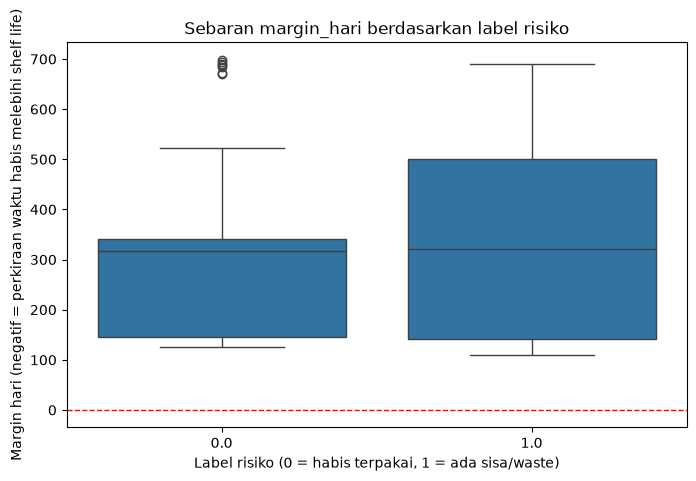

In [18]:
# diagnostik cepat sebelum ubah-ubah model lagi
# margin_hari = selisih antara waktu yang tersedia (shelf_life_hari) dengan
# perkiraan waktu yang dibutuhkan buat habis (rasio_stok_terhadap_demand)
# kalau margin negatif, artinya stok diperkirakan belum habis saat kadaluwarsa
# (harusnya berkorelasi kuat dengan label_risiko = 1)
data_training["margin_hari"] = (
    data_training["shelf_life_hari"] - data_training["rasio_stok_terhadap_demand"]
)

print("Ringkasan margin_hari per kelompok label:")
print(data_training.groupby("label_risiko")["margin_hari"].describe())

# visualisasi biar kelihatan jelas seberapa tumpang tindih dua kelompok ini
plt.figure(figsize=(8, 5))
sns.boxplot(data=data_training, x="label_risiko", y="margin_hari")
plt.title("Sebaran margin_hari berdasarkan label risiko")
plt.xlabel("Label risiko (0 = habis terpakai, 1 = ada sisa/waste)")
plt.ylabel("Margin hari (negatif = perkiraan waktu habis melebihi shelf life)")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.show()

#### 13.2 Pengcheckan Fitur Posisi Antrean

Ringkasan jumlah_batch_di_depan per kelompok label:
              count      mean       std  min  25%  50%  75%   max
label_risiko                                                     
0.0            61.0  3.918033  2.917162  0.0  1.0  4.0  6.0  11.0
1.0           107.0  3.906542  2.992231  0.0  1.0  4.0  6.0  12.0


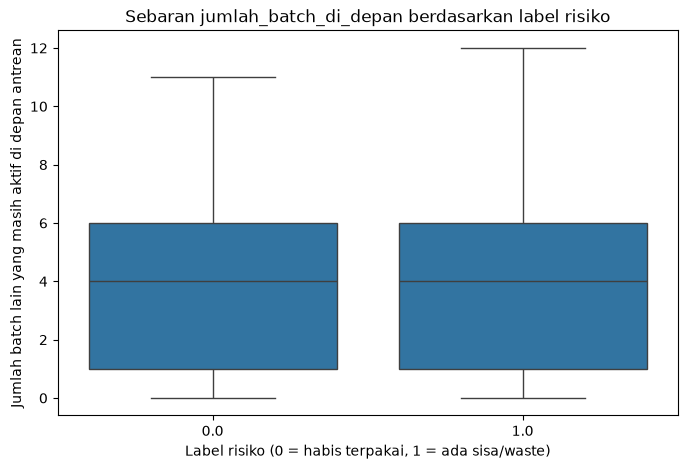

In [19]:
# cek dulu apakah fitur posisi antrean beneran memisahkan kedua kelompok label
# sebelum dimasukkan ke model, sama seperti pengecekan margin_hari sebelumnya
print("Ringkasan jumlah_batch_di_depan per kelompok label:")
print(data_training.groupby("label_risiko")["jumlah_batch_di_depan"].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=data_training, x="label_risiko", y="jumlah_batch_di_depan")
plt.title("Sebaran jumlah_batch_di_depan berdasarkan label risiko")
plt.xlabel("Label risiko (0 = habis terpakai, 1 = ada sisa/waste)")
plt.ylabel("Jumlah batch lain yang masih aktif di depan antrean")
plt.show()

### **14. Model Definition**
Baseline model dan setup cross-validation

In [20]:
# skema cross validation, pakai repeated stratified k-fold karena data
# training cuma 168 baris, terlalu kecil untuk percaya satu kali split saja
# stratified menjaga proporsi label 0/1 tetap konsisten di tiap fold
# repeated mengulang proses itu beberapa kali dengan pembagian acak berbeda,
# supaya hasil metrik tidak cuma bergantung pada satu kali kebetulan pembagian
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

metrik_yang_diukur = ["precision", "recall", "f1", "roc_auc"]

# baseline 1, dummy classifier yang selalu menebak kelas mayoritas
# ini bukan model, ini garis dasar pembanding wajib untuk data imbang seperti ini
baseline_dummy = DummyClassifier(strategy="most_frequent")

hasil_dummy = cross_validate(baseline_dummy, X, y, cv=cv, scoring=metrik_yang_diukur)

print("=== Baseline 1: Dummy Classifier (tebak kelas mayoritas terus) ===")
for metrik in metrik_yang_diukur:
    skor = hasil_dummy[f"test_{metrik}"]
    print(f"{metrik:10s}: rata-rata {skor.mean():.3f} (std {skor.std():.3f})")

# baseline 2, logistic regression, perlu one-hot encoding manual untuk kolom
# kategorikal karena logistic regression tidak bisa terima tipe category
# langsung seperti XGBoost/LightGBM
# perbaikan preprocessing, sekarang bulan_terima ikut di-one-hot (sifatnya
# siklik/nominal, bukan berjenjang), dan fitur numerik lainnya di-scale
# supaya logistic regression tidak salah baca skala antar fitur
kolom_kategorikal = ["kategori", "gudang_id", "bulan_terima"]
kolom_numerik = [
    "total_masuk", "shelf_life_hari",
    "rata_rata_demand_obat_gudang", "rasio_stok_terhadap_demand",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("kategorikal", OneHotEncoder(handle_unknown="ignore"), kolom_kategorikal),
        ("numerik", StandardScaler(), kolom_numerik),
    ]
)

# class_weight seimbang, supaya model tidak cuma malas menebak kelas mayoritas
# terus menerus demi akurasi semu, mengingat distribusi 61:107 sedikit njomplang
baseline_logreg = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

hasil_logreg = cross_validate(baseline_logreg, X, y, cv=cv, scoring=metrik_yang_diukur)

print("=== Baseline 2: Logistic Regression ===")
for metrik in metrik_yang_diukur:
    skor = hasil_logreg[f"test_{metrik}"]
    print(f"{metrik:10s}: rata-rata {skor.mean():.3f} (std {skor.std():.3f})")

=== Baseline 1: Dummy Classifier (tebak kelas mayoritas terus) ===
precision : rata-rata 0.637 (std 0.011)
recall    : rata-rata 1.000 (std 0.000)
f1        : rata-rata 0.778 (std 0.008)
roc_auc   : rata-rata 0.500 (std 0.000)
=== Baseline 2: Logistic Regression ===
precision : rata-rata 0.665 (std 0.083)
recall    : rata-rata 0.557 (std 0.078)
f1        : rata-rata 0.604 (std 0.073)
roc_auc   : rata-rata 0.545 (std 0.097)


In [21]:
# uji terkontrol, logistic regression TANPA bulan_terima
# tujuannya isolasi apakah bulan_terima yang kemarin ditambahkan
# justru menambah noise pada dataset sekecil ini (168 baris)
kolom_kategorikal_tanpa_bulan = ["kategori", "gudang_id"]
kolom_numerik = [
    "total_masuk", "shelf_life_hari",
    "rata_rata_demand_obat_gudang", "rasio_stok_terhadap_demand",
]

preprocessor_tanpa_bulan = ColumnTransformer(
    transformers=[
        ("kategorikal", OneHotEncoder(handle_unknown="ignore"), kolom_kategorikal_tanpa_bulan),
        ("numerik", StandardScaler(), kolom_numerik),
    ]
)

logreg_tanpa_bulan = Pipeline([
    ("preprocessing", preprocessor_tanpa_bulan),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

X_tanpa_bulan = data_training[kolom_kategorikal_tanpa_bulan + kolom_numerik]

hasil_tanpa_bulan = cross_validate(
    logreg_tanpa_bulan, X_tanpa_bulan, y, cv=cv, scoring=metrik_yang_diukur
)

print("=== Logistic Regression TANPA bulan_terima ===")
for metrik in metrik_yang_diukur:
    skor = hasil_tanpa_bulan[f"test_{metrik}"]
    print(f"{metrik:10s}: rata-rata {skor.mean():.3f} (std {skor.std():.3f})")

=== Logistic Regression TANPA bulan_terima ===
precision : rata-rata 0.684 (std 0.103)
recall    : rata-rata 0.549 (std 0.098)
f1        : rata-rata 0.605 (std 0.084)
roc_auc   : rata-rata 0.557 (std 0.104)


### **15. Uji Konfirmasi Model**

In [22]:
# uji konfirmasi, logistic regression + fitur posisi antrean
# ini untuk menutup pertanyaan secara definitif dengan angka CV yang sebenarnya,
# bukan cuma dugaan dari boxplot dan describe() saja
kolom_kategorikal_full = ["kategori", "gudang_id"]
kolom_numerik_full = [
    "total_masuk", "shelf_life_hari",
    "rata_rata_demand_obat_gudang", "rasio_stok_terhadap_demand",
    "jumlah_batch_di_depan", "stok_menumpuk_di_depan",
]

preprocessor_full = ColumnTransformer(
    transformers=[
        ("kategorikal", OneHotEncoder(handle_unknown="ignore"), kolom_kategorikal_full),
        ("numerik", StandardScaler(), kolom_numerik_full),
    ]
)

logreg_full = Pipeline([
    ("preprocessing", preprocessor_full),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

X_full = data_training[kolom_kategorikal_full + kolom_numerik_full]

hasil_full = cross_validate(logreg_full, X_full, y, cv=cv, scoring=metrik_yang_diukur)

print("=== Logistic Regression + fitur posisi antrean (tanpa bulan_terima) ===")
for metrik in metrik_yang_diukur:
    skor = hasil_full[f"test_{metrik}"]
    print(f"{metrik:10s}: rata-rata {skor.mean():.3f} (std {skor.std():.3f})")

=== Logistic Regression + fitur posisi antrean (tanpa bulan_terima) ===
precision : rata-rata 0.674 (std 0.100)
recall    : rata-rata 0.532 (std 0.101)
f1        : rata-rata 0.589 (std 0.080)
roc_auc   : rata-rata 0.544 (std 0.101)


In [23]:
# XGBoost dan LightGBM
# fitur final untuk model berbasis pohon, sertakan fitur posisi antrean
# meskipun lemah di uji univariate, model pohon otomatis mengabaikan fitur
# yang tidak berguna lewat feature importance, jadi aman disertakan
kolom_fitur_final = [
    "kategori", "gudang_id",
    "total_masuk", "shelf_life_hari",
    "rata_rata_demand_obat_gudang", "rasio_stok_terhadap_demand",
    "jumlah_batch_di_depan", "stok_menumpuk_di_depan",
]

X_tree = data_training[kolom_fitur_final]

# scale_pos_weight adalah versi XGBoost dari class_weight='balanced',
# menyeimbangkan kontribusi kelas minoritas (label 0) saat training
jumlah_negatif = (y == 0).sum()
jumlah_positif = (y == 1).sum()
scale_pos_weight = jumlah_negatif / jumlah_positif

# max_depth dan n_estimators sengaja dijaga kecil, data training cuma 168
# baris, model pohon yang terlalu dalam gampang sekali overfitting di sini
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    random_state=42,
)

hasil_xgb = cross_validate(model_xgb, X_tree, y, cv=cv, scoring=metrik_yang_diukur)

print("=== XGBoost ===")
for metrik in metrik_yang_diukur:
    skor = hasil_xgb[f"test_{metrik}"]
    print(f"{metrik:10s}: rata-rata {skor.mean():.3f} (std {skor.std():.3f})")

model_lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    min_child_samples=10,
    class_weight="balanced",
    random_state=42,
    verbose=-1,
)

hasil_lgbm = cross_validate(model_lgbm, X_tree, y, cv=cv, scoring=metrik_yang_diukur)

print("\n=== LightGBM ===")
for metrik in metrik_yang_diukur:
    skor = hasil_lgbm[f"test_{metrik}"]
    print(f"{metrik:10s}: rata-rata {skor.mean():.3f} (std {skor.std():.3f})")

=== XGBoost ===
precision : rata-rata 0.612 (std 0.061)
recall    : rata-rata 0.564 (std 0.064)
f1        : rata-rata 0.585 (std 0.052)
roc_auc   : rata-rata 0.449 (std 0.074)

=== LightGBM ===
precision : rata-rata 0.627 (std 0.059)
recall    : rata-rata 0.544 (std 0.076)
f1        : rata-rata 0.579 (std 0.053)
roc_auc   : rata-rata 0.481 (std 0.082)


In [24]:
# ringkasan perbandingan semua model yang sudah diuji sejauh ini
ringkasan_model = pd.DataFrame({
    "Dummy": {m: hasil_dummy[f"test_{m}"].mean() for m in metrik_yang_diukur},
    "LogReg (semua fitur)": {m: hasil_logreg[f"test_{m}"].mean() for m in metrik_yang_diukur},
    "LogReg (tanpa bulan_terima)": {m: hasil_tanpa_bulan[f"test_{m}"].mean() for m in metrik_yang_diukur},
    "LogReg (+ posisi antrean)": {m: hasil_full[f"test_{m}"].mean() for m in metrik_yang_diukur},
    "XGBoost": {m: hasil_xgb[f"test_{m}"].mean() for m in metrik_yang_diukur},
    "LightGBM": {m: hasil_lgbm[f"test_{m}"].mean() for m in metrik_yang_diukur},
}).T

print("Ringkasan perbandingan seluruh model:")
print(ringkasan_model.round(3))

Ringkasan perbandingan seluruh model:
                             precision  recall     f1  roc_auc
Dummy                            0.637   1.000  0.778    0.500
LogReg (semua fitur)             0.665   0.557  0.604    0.545
LogReg (tanpa bulan_terima)      0.684   0.549  0.605    0.557
LogReg (+ posisi antrean)        0.674   0.532  0.589    0.544
XGBoost                          0.612   0.564  0.585    0.449
LightGBM                         0.627   0.544  0.579    0.481


Model klasifikasi risiko kadaluwarsa diuji dengan tiga pendekatan (Logistic Regression, XGBoost, LightGBM) menggunakan repeated stratified 5-fold cross-validation. Hasil terbaik (Logistic Regression, AUC 0.557) masih mendekati baseline dummy classifier (AUC 0.5), dan model tree-based (XGBoost, LightGBM) justru berkinerja di bawah baseline (AUC 0.449 dan 0.481), indikasi overfitting akibat kapasitas model yang jauh melebihi ukuran data training (168 baris). Dua fitur turunan (margin_hari dan posisi antrean FEFO) diuji dan keduanya tidak menunjukkan pemisahan yang berarti antar kelompok label. Kesimpulan yang diambil, outcome waste/tidak-waste pada level batch kemungkinan besar didominasi oleh variasi acak konsumsi harian (proses Poisson) pada data simulasi, bukan oleh karakteristik batch yang bisa diprediksi. Ini dilaporkan apa adanya sebagai keterbatasan data simulasi, bukan disembunyikan.

### **16. Model Training & Evaluation**

In [25]:
# fit model final (logreg tanpa bulan_terima) pakai seluruh data training
# CV sebelumnya cuma untuk mengukur performa, bukan model yang dipakai final
model_final = Pipeline([
    ("preprocessing", preprocessor_tanpa_bulan),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

model_final.fit(X_tanpa_bulan, y)

# terapkan ke batch yang masih berjalan (data_scoring), ini use case sebenarnya
X_scoring = data_scoring[kolom_kategorikal_tanpa_bulan + kolom_numerik]
data_scoring["probabilitas_risiko"] = model_final.predict_proba(X_scoring)[:, 1]

# bagi jadi kategori risiko berbasis persentil, bukan ambang tetap (misal >0.7)
# karena model ini lemah, skor probabilitasnya kemungkinan mengumpul di tengah,
# ambang tetap bisa saja tidak menghasilkan pembagian yang berguna secara bisnis
batas_tinggi = data_scoring["probabilitas_risiko"].quantile(0.80)
batas_sedang = data_scoring["probabilitas_risiko"].quantile(0.50)

def kategorikan_risiko(p):
    if p >= batas_tinggi:
        return "Tinggi"
    elif p >= batas_sedang:
        return "Sedang"
    else:
        return "Rendah"

data_scoring["kategori_risiko"] = data_scoring["probabilitas_risiko"].apply(kategorikan_risiko)

print("Distribusi kategori risiko pada batch yang masih berjalan:")
print(data_scoring["kategori_risiko"].value_counts())
print()
print(data_scoring[[
    "batch_id", "obat_id", "gudang_id", "probabilitas_risiko", "kategori_risiko"
]].head(10))

Distribusi kategori risiko pada batch yang masih berjalan:
kategori_risiko
Rendah    900
Sedang    540
Tinggi    361
Name: count, dtype: int64

           batch_id  obat_id gudang_id  probabilitas_risiko kategori_risiko
13  AMX-20240727-01  OBT0064      GD03             0.571181          Rendah
18  IBU-20240727-01  OBT0259      GD01             0.406981          Rendah
19  IBU-20240727-01  OBT0259      GD02             0.830817          Tinggi
20  IBU-20240727-01  OBT0259      GD03             0.690656          Sedang
21  IBU-20240727-01  OBT0259      GD04             0.548567          Rendah
22  RAN-20240727-01  OBT0524      GD03             0.741721          Tinggi
23  RAN-20240727-01  OBT0524      GD02             0.778080          Tinggi
24  LOR-20240727-01  OBT0398      GD01             0.470554          Rendah
25  LOR-20240727-01  OBT0398      GD02             0.720484          Sedang
26  LOR-20240727-01  OBT0398      GD03             0.785777          Tinggi


### **17. Update Resul kedalam Database gold.pred_expiry_risk**

In [26]:
# tulis hasil ke gold.pred_expiry_risk
# truncate dulu baru append, supaya idempotent (aman dijalankan berkali-kali)
# tanpa merusak struktur tabel yang sudah didefinisikan sisi Data Engineer
hasil_untuk_gold = data_scoring[["batch_id", "probabilitas_risiko", "kategori_risiko"]].copy()
hasil_untuk_gold["dibuat_pada"] = datetime.now(timezone.utc)

with engine.begin() as koneksi:
    koneksi.execute(text("TRUNCATE TABLE gold.pred_expiry_risk"))

hasil_untuk_gold.to_sql(
    "pred_expiry_risk", engine, schema="gold", if_exists="append", index=False,
)

print(f"Berhasil menulis {len(hasil_untuk_gold)} baris ke gold.pred_expiry_risk")

Berhasil menulis 1801 baris ke gold.pred_expiry_risk


### **18. Model Saving**

In [27]:
# simpan model final untuk audit trail dan reproducibility
# Streamlit TIDAK akan memuat file ini secara langsung (baca alasannya di
# catatan project), tapi ini penting supaya ada jejak persis model mana
# yang menghasilkan prediksi yang tersimpan di gold.pred_expiry_risk

os.makedirs("../models", exist_ok=True)
joblib.dump(model_final, "../models/model_expiry_risk_logreg.pkl")

print("Model final disimpan di models/model_expiry_risk_logreg.pkl")

Model final disimpan di models/model_expiry_risk_logreg.pkl
